In [1]:
import pandas as pd

# --- Funkcja do wczytywania Enrichr/Reactome plików ---
def load_reactome(file_path, cell_type):
    
    # Próba wczytania jako CSV
    try:
        df = pd.read_csv(file_path)
    except:
        df = pd.read_excel(file_path, header=None)
        df = df[0].str.split(",", expand=True)

    # Jeśli plik ma jedną kolumnę (csv zapisany dziwnie)
    if df.shape[1] == 1:
        df = df[0].str.split(",", expand=True)

    # Standardowy układ Enrichr
    df.columns = [
        "Index",
        "Term",
        "P_value",
        "Adjusted_P_value",
        "Overlap",
        "Combined_Score"
    ] + [f"Extra_{i}" for i in range(df.shape[1] - 6)]

    # Konwersje typów
    df["Adjusted_P_value"] = pd.to_numeric(df["Adjusted_P_value"], errors="coerce")
    df["P_value"] = pd.to_numeric(df["P_value"], errors="coerce")
    df["Combined_Score"] = pd.to_numeric(df["Combined_Score"], errors="coerce")

    # Wyciągnięcie liczby genów z overlap (np. "9/112")
    df["Gene_Number"] = df["Overlap"].str.split("/").str[0].astype(float)

    # Dodanie cell type
    df["Cell_Type"] = cell_type

    # Zostaw tylko potrzebne kolumny
    df = df[[
        "Cell_Type",
        "Term",
        "Adjusted_P_value",
        "P_value",
        "Combined_Score",
        "Gene_Number"
    ]]

    return df


# --- Wczytanie wszystkich plików ---
gm = load_reactome("export/gm12878_reactomes.csv", "GM12878")
hffc6 = load_reactome("export/hffc6_reactomes.csv", "HFFc6")
h1esc = load_reactome("export/h1esc_reactomes.csv", "H1-ESC")

# --- Połączenie ---
all_terms = pd.concat([gm, hffc6, h1esc], ignore_index=True)

# --- Filtrowanie istotnych ---
sig_terms = all_terms[all_terms["Adjusted_P_value"] < 0.05].copy()

# Posortuj
sig_terms = sig_terms.sort_values(["Cell_Type", "Adjusted_P_value"])

sig_terms.reset_index(drop=True)

,Cell_Type,Term,Adjusted_P_value,P_value,Combined_Score,Gene_Number
0,GM12878,Cytokine Signaling in Immune System,0.000032,5.188068e-08,49.931513,37.0
1,GM12878,Immune System,0.000032,7.723141e-08,35.222334,72.0
2,GM12878,GPVI-mediated Activation Cascade,0.000643,2.293600e-06,182.998820,7.0
3,GM12878,Signaling by Interleukins,0.004474,2.127736e-05,31.759712,22.0
4,GM12878,Innate Immune System,0.006268,3.726772e-05,21.643258,40.0
5,GM12878,Toll-like Receptor Cascades,0.009481,6.763871e-05,40.397952,12.0
6,GM12878,"Interleukin-3, Interleukin-5 and GM-CSF Signaling",0.023567,1.961586e-04,68.498859,6.0
7,GM12878,Toll Like Receptor 4 (TLR4) Cascade,0.033571,3.193416e-04,32.979774,10.0
8,H1-ESC,Epithelial-Mesenchymal Transition (EMT) During...,0.007774,9.388621e-06,656.865131,4.0
9,HFFc6,Extracellular Matrix Organization,0.000114,1.349182e-07,62.892779,23.0


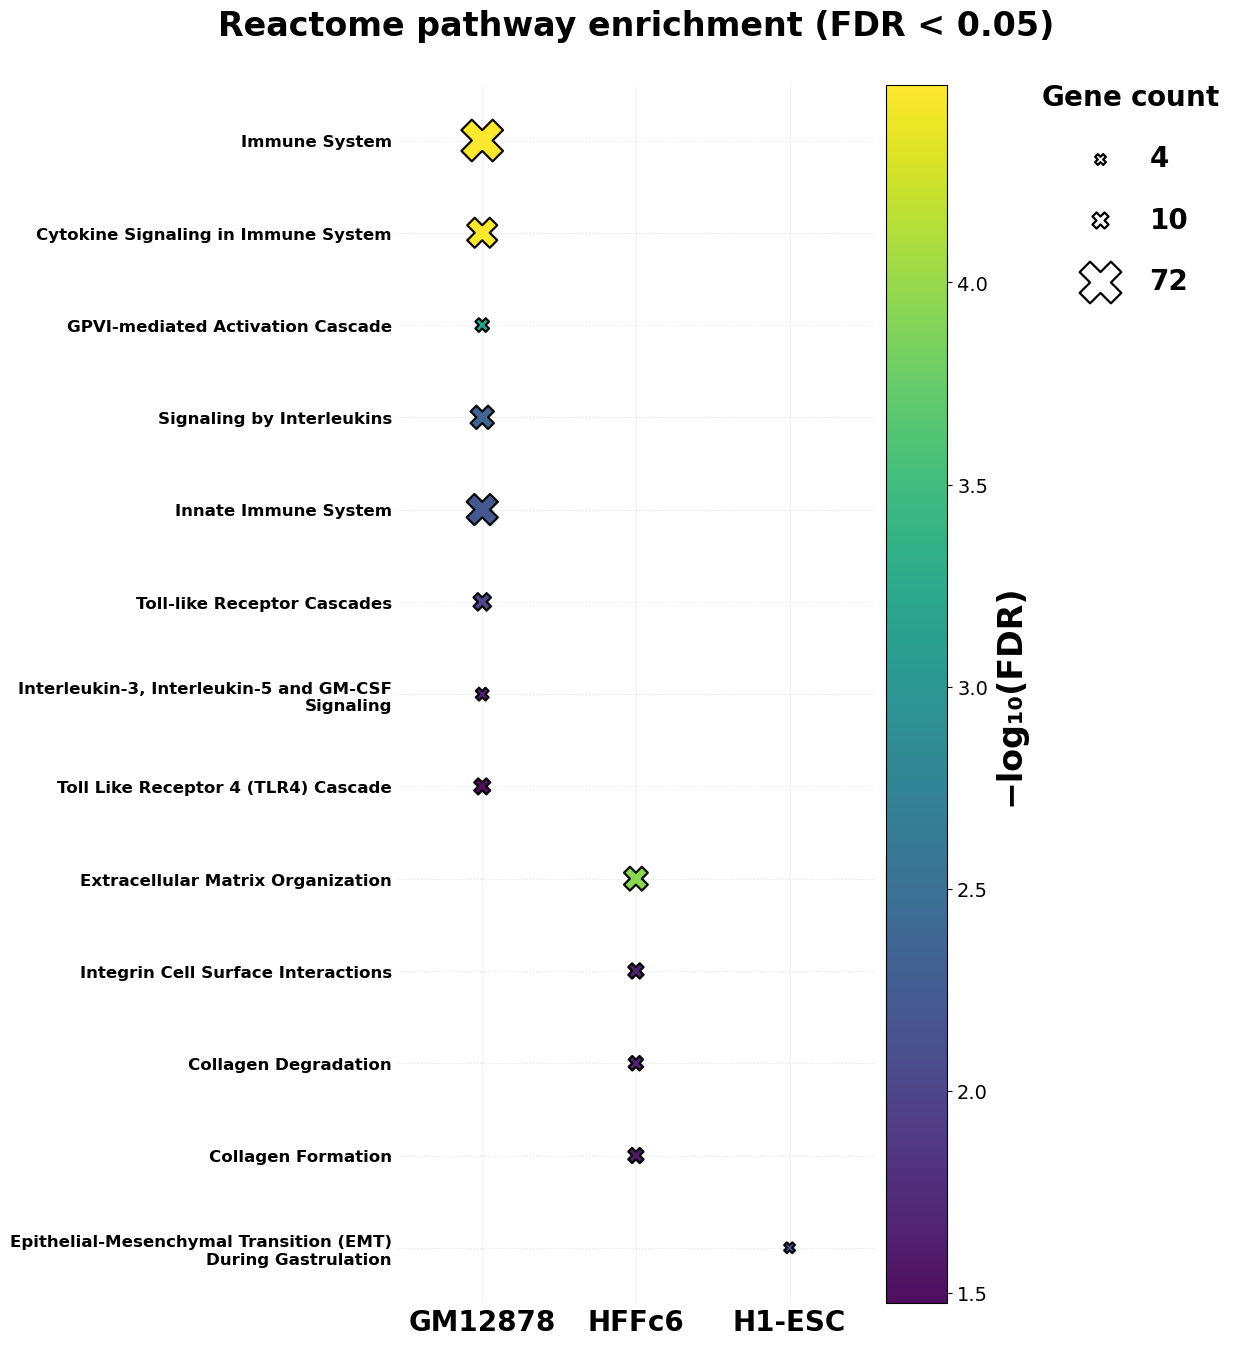

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- dane ---
df = sig_terms.copy()
df["minus_log10_adjP"] = -np.log10(df["Adjusted_P_value"])

# (opcjonalnie) jeśli chcesz tylko FDR < 0.05:
# df = df[df["Adjusted_P_value"] < 0.05].copy()

# 1) kolejność na osi X: GM -> HFF -> H1
cell_order = ["GM12878", "HFFc6", "H1-ESC"]  # <- zgodnie z Twoim życzeniem
df["Cell_Type"] = pd.Categorical(df["Cell_Type"], categories=cell_order, ordered=True)

# 2) sort: najpierw cell line, potem Gene_Number (malejąco)
#    + tie-breaker po istotności
df = df.sort_values(
    ["Cell_Type", "minus_log10_adjP", "Gene_Number"],
    ascending=[True, False, False]
)

# 3) Term jako kategorie w kolejności pojawienia się po sortowaniu
df["Term"] = df["Term"].astype(str)
term_order = df["Term"].drop_duplicates().tolist()
df["Term"] = pd.Categorical(df["Term"], categories=term_order[::-1], ordered=True)

# --- mapowanie na osie liczbowe ---
# --- compact X spacing ---
x_spacing = 0.45   # <--- decrease this to make columns closer (e.g. 0.45–0.65)

x_positions = np.arange(len(cell_order)) * x_spacing
x_map = dict(zip(cell_order, x_positions))

y_cats = df["Term"].cat.categories
y_map = {t: i for i, t in enumerate(y_cats)}

x = df["Cell_Type"].map(x_map).to_numpy()
y = df["Term"].map(y_map).to_numpy()

# --- rozmiary (Gene_Number -> area) ---
size_min, size_max = 60, 900
gmin, gmax = df["Gene_Number"].min(), df["Gene_Number"].max()
s = np.interp(df["Gene_Number"], (gmin, gmax), (size_min, size_max))

# --- kolor (−log10(FDR)) ---
v = df["minus_log10_adjP"].to_numpy()
norm = mpl.colors.Normalize(vmin=v.min(), vmax=v.max())
cmap = mpl.cm.viridis

# --- figure: białe tło ---
fig, ax = plt.subplots(figsize=(12, 14))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sc = ax.scatter(
    x, y,
    s=s,
    c=v,
    cmap=cmap,
    norm=norm,
    marker="X",
    linewidths=1.6,
    edgecolors="black",
    alpha=0.95,
    zorder=3
)

# osie i siatka
ax.set_xticks(x_positions)
ax.set_xticklabels(cell_order, fontsize=20, fontweight="bold")
ax.set_yticks(range(len(y_cats)))

ax.set_xlim(x_positions.min() - 0.25, x_positions.max() + 0.25)

def split_label(label, max_len=40):
    if len(label) <= max_len:
        return label
    else:
        # Znajdź ostatnią spację przed max_len
        split_pos = label.rfind(" ", 0, max_len)
        if split_pos == -1:  # jeśli nie ma spacji, podziel na max_len
            split_pos = max_len
        return label[:split_pos] + "\n" + split_label(label[split_pos:].strip(), max_len)
y_cats_truncated = [split_label(t, max_len=40) for t in y_cats]

ax.set_yticklabels(y_cats_truncated, fontsize=12, fontweight="bold")

ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.35)
ax.grid(axis="x", linestyle="-", linewidth=0.8, alpha=0.15)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="both", length=0)

ax.set_title("Reactome pathway enrichment (FDR < 0.05)", fontsize=24, pad=36, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("")

# --- colorbar ---
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("−log₁₀(FDR)", fontsize=24, weight="bold")
cbar.ax.tick_params(labelsize=14)

# --- legenda rozmiaru z przerwą (nie nachodzi) ---
def size_for(val):
    if gmax == gmin:
        return (size_min + size_max) / 2
    return np.interp(val, (gmin, gmax), (size_min, size_max))

# wybierz 3 poziomy, ale rozsuń je (min / median / max zwykle jest OK)
levels = [int(gmin), int(round(df["Gene_Number"].median())), int(gmax)]

handles = []
labels = []
for gv in levels:
    h = ax.scatter([], [], s=size_for(gv), marker="X",
                   facecolors="white", edgecolors="black",
                   linewidths=1.6)
    handles.append(h)
    labels.append(str(gv))

leg = ax.legend(
    handles, labels,
    title=r"$\bf{Gene\ count}$",
    loc="upper left",
    bbox_to_anchor=(1.30, 1.02),
    frameon=False,
    scatterpoints=1,
    labelspacing=1.2,     # <- KLUCZ: przerwa między wpisami
    handletextpad=0.8,    # <- odstęp marker–tekst
    borderpad=0.3,
    fontsize=16,
    title_fontsize=20,
    prop={'weight':'bold', 'size': 20}
)

# --- layout fix: prevent left overflow of long y-labels ---
plt.subplots_adjust(
    left=0.42,   # more space for long pathway names
    right=0.90,  # reserve space for legend
    top=0.93,
    bottom=0.06
)

# optionally align y tick labels to the right (cleaner look)
for tick in ax.get_yticklabels():
    tick.set_horizontalalignment("right")

# plt.tight_layout()
plt.show()

# Jeśli zapisujesz do publikacji:
# fig.savefig("reactome_dotplot_white.pdf", bbox_inches="tight")
fig.savefig("figs/reactome_dotplot_white.png", dpi=600, bbox_inches="tight")

In [3]:
sig_terms

,Cell_Type,Term,Adjusted_P_value,P_value,Combined_Score,Gene_Number
0,GM12878,Cytokine Signaling in Immune System,0.000032,5.188068e-08,49.931513,37.0
1,GM12878,Immune System,0.000032,7.723141e-08,35.222334,72.0
2,GM12878,GPVI-mediated Activation Cascade,0.000643,2.293600e-06,182.998820,7.0
3,GM12878,Signaling by Interleukins,0.004474,2.127736e-05,31.759712,22.0
4,GM12878,Innate Immune System,0.006268,3.726772e-05,21.643258,40.0
5,GM12878,Toll-like Receptor Cascades,0.009481,6.763871e-05,40.397952,12.0
6,GM12878,"Interleukin-3, Interleukin-5 and GM-CSF Signaling",0.023567,1.961586e-04,68.498859,6.0
7,GM12878,Toll Like Receptor 4 (TLR4) Cascade,0.033571,3.193416e-04,32.979774,10.0
1684,H1-ESC,Epithelial-Mesenchymal Transition (EMT) During...,0.007774,9.388621e-06,656.865131,4.0
841,HFFc6,Extracellular Matrix Organization,0.000114,1.349182e-07,62.892779,23.0


In [4]:
len(sig_terms)

13